# Otimização de preços: viabilidade antes da margem

Este notebook responde por que a formulação oficial é infactível, quais regras entram em conflito e qual é a menor alteração operacional que recupera a viabilidade. A curva do Notebook 2.1 permanece congelada: nenhum coeficiente, suporte, *smearing* ou cenário é reestimado aqui.

## 1. Contrato e reprodutibilidade

**Pergunta.** Os artefatos estatísticos, dados de desenvolvimento e restrições da instância são compatíveis?

**Método.** O código importa funções promovidas para `src/`, valida o hash v1 da curva, lê custo somente até 31/10/2025 e usa a alíquota de 7% informada pela equipe. O holdout não é lido até a comparação ex post final. A semente é fixa em 42.

In [1]:
from dataclasses import replace
import json
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.modeling.demand_curve import load_artifact, validate_artifact
from src.optimization.price_schedule import (
    PriceProblem, build_horizon, demand_vector, diagnose_feasibility,
    margin_vector, minimum_relaxation, optimize_prices, pareto_relaxations,
    problem_from_frames, select_cost_forecast, validate_prices, volume_relaxations,
)

SEED = 42
MODELS = ROOT / 'models'
DATA = ROOT / 'data'
TABLES = ROOT / 'reports' / 'tables'
FIGURES = ROOT / 'reports' / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

artifact = load_artifact(MODELS / 'demand_curve_champion_livro.json')
uncertainty = load_artifact(MODELS / 'demand_curve_uncertainty_livro.json')
validate_artifact(artifact)
if uncertainty['model_core_sha256'] != artifact['model_core_sha256']:
    raise ValueError('Curva e incerteza não pertencem ao mesmo núcleo congelado.')
development = pd.read_csv(
    DATA / 'processed' / 'minerva_modelagem_treino.csv', parse_dates=['data']
)
restrictions = pd.read_csv(DATA / 'interim' / 'minerva_restricoes.csv')
horizon = build_horizon()
initial_price = float(development.sort_values('data')['preco_kg'].iloc[-1])
pd.DataFrame({
    'item': ['hash da curva', 'fim do desenvolvimento', 'preço inicial', 'dias no horizonte'],
    'valor': [artifact['model_core_sha256'], development['data'].max().date(), initial_price, len(horizon)],
})

2026-10-03 13:26:15.095 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas


,item,valor
0,hash da curva,7ab845c977f33d7d1b59b12e68fa41adef083e22f6a209...
1,fim do desenvolvimento,2025-10-31
2,preço inicial,1318.919594
3,dias no horizonte,10


**Interpretação.** O núcleo estatístico é reproduzido pelo hash registrado, o histórico de decisão termina em 31/10/2025 e o preço inicial é R$ 1.318,92/kg. Assim, custo e política podem ser congelados sem consultar resultados futuros.

## 2. Seleção temporal da premissa de custo

**Pergunta.** Qual regra simples prevê melhor o custo unitário ponderado das duas semanas seguintes?

**Método.** Em sextas-feiras com pelo menos quatro semanas anteriores e duas semanas futuras dentro do desenvolvimento, comparam-se último valor, médias ponderadas de 1, 2 e 4 semanas, média expansiva e média exponencial. MAE é primária; regras até 5% do melhor são equivalentes. Limitação: oito origens móveis ainda representam uma amostra pequena.

In [2]:
cost_selection = select_cost_forecast(development)
cost_details = cost_selection['details']
cost_summary = cost_selection['summary']
cost_details.to_csv(TABLES / '03_custo_validacao_detalhes.csv', index=False)
cost_summary.to_csv(TABLES / '03_custo_validacao_resumo.csv', index=False)
display(cost_summary[['rotulo', 'MAE', 'RMSE', 'vies', 'desvio_erro', 'equivalente_5pct']])
print(f"Regra congelada: {cost_selection['label']}")
print(f"Custo previsto: R$ {cost_selection['forecast_cost_kg']:.2f}/kg")
print(
    f"Faixa de sensibilidade: R$ {cost_selection['low_cost_kg']:.2f} a "
    f"R$ {cost_selection['high_cost_kg']:.2f}/kg"
)

,rotulo,MAE,RMSE,vies,desvio_erro,equivalente_5pct
0,Média ponderada — 4 semanas,9.267160,11.663063,-8.176609,8.891094,True
1,"Média móvel exponencial (α=0,30)",10.267269,11.559595,-5.505262,10.866269,False
2,Média ponderada — 2 semanas,10.473905,12.261714,-6.930764,10.813437,False
3,Último custo unitário,10.594277,11.944219,-3.744881,12.125073,False
4,Média ponderada expansiva,10.885377,12.768738,-10.630763,7.561371,False
5,Média ponderada — 1 semana,10.896760,11.882814,-5.700610,11.146008,False


Regra congelada: Média ponderada — 4 semanas
Custo previsto: R$ 988.84/kg
Faixa de sensibilidade: R$ 988.68 a R$ 1009.38/kg


**Interpretação.** A média ponderada das últimas quatro semanas tem o menor MAE e é a única dentro do limiar de equivalência de 5%. Ela fixa R$ 988,84/kg como custo central. Erros continuam podendo refletir mudanças de regime; por isso os quantis temporais alimentam a sensibilidade, não uma falsa precisão diária.

## 3. Formulação oficial estrita

**Pergunta.** Qual problema é efetivamente resolvido antes de qualquer relaxação?

**Método.** Metas, tolerância e variação vêm da planilha; o suporte vem da curva; o primeiro preço liga-se a 31/10. A margem diária é `[(1 - 0,07) × preço - custo] × demanda`. O diagnóstico usa envelopes alcançáveis antes de tentar maximizar margem.

In [3]:
problem = problem_from_frames(
    artifact, restrictions, horizon=horizon,
    unit_cost=cost_selection['forecast_cost_kg'],
    initial_price=initial_price, tax_rate=0.07,
    uncertainty=uncertainty,
)
official = optimize_prices(problem, seed=SEED)
inputs_table = pd.DataFrame({
    'parâmetro': ['meta semanal', 'tolerância', 'limite inferior', 'variação máxima', 'imposto', 'custo'],
    'valor': [
        problem.targets['semana_1'], problem.tolerance,
        problem.targets['semana_1'] * (1 - problem.tolerance),
        problem.daily_variation, problem.tax_rate, problem.costs[0],
    ],
})
display(inputs_table)
print('Status oficial:', official['status'])
assert official['status'] == 'infeasible' and official['daily'] is None

,parâmetro,valor
0,meta semanal,165.000000
1,tolerância,0.300000
2,limite inferior,115.500000
3,variação máxima,2.000000
4,imposto,0.070000
5,custo,988.842561


Status oficial: infeasible


**Interpretação.** A formulação oficial é preservada e retorna infactível; deliberadamente não há tabela diária que pareça uma recomendação. A divergência documental permanece explícita: 30% da instância é o caso principal, enquanto 5% é apenas sensibilidade.

## 4. Fontes da infactibilidade

**Pergunta.** A meta falha por causa do suporte, do preço inicial, da estabilidade diária ou da combinação?

**Método.** Acrescentam-se as regras em sequência aninhada. Como a curva é decrescente, o caminho de preços mais baixo alcançável define o maior volume simultâneo. O envelope é uma análise preditiva condicional, não uma alegação causal.

In [4]:
nested_specs = {
    'somente_suporte': (None, None),
    'suporte_preco_inicial': (problem.daily_variation, None),
    'suporte_preco_inicial_variacao': (problem.daily_variation, problem.daily_variation),
}
nested_rows = []
nested_diagnostics = {}
for specification, (initial_delta, daily_delta) in nested_specs.items():
    diagnostic = diagnose_feasibility(
        problem, initial_delta=initial_delta, daily_delta=daily_delta
    )
    nested_diagnostics[specification] = diagnostic
    for week, values in diagnostic['weeks'].items():
        nested_rows.append({'especificacao': specification, 'semana': week, **values})
nested_table = pd.DataFrame(nested_rows)
nested_table.to_csv(TABLES / '03_diagnostico_aninhado.csv', index=False)
display(nested_table[[
    'especificacao', 'semana', 'lower_kg', 'maximum_reachable_kg',
    'shortage_kg', 'potentially_feasible',
]])
official_daily_envelope = pd.DataFrame(
    official['diagnostic']['low_path_details']
)
official_daily_envelope.to_csv(
    TABLES / '03_envelope_oficial_diario.csv', index=False
)
display(official_daily_envelope[[
    'date', 'weekday', 'price', 'absolute_change',
    'variation_slack', 'at_variation_limit', 'at_lower_support',
]])

,especificacao,semana,lower_kg,maximum_reachable_kg,shortage_kg,potentially_feasible
0,somente_suporte,semana_1,115.5,237.290896,0.000000,True
1,somente_suporte,semana_2,115.5,237.290896,0.000000,True
2,suporte_preco_inicial,semana_1,115.5,199.394326,0.000000,True
3,suporte_preco_inicial,semana_2,115.5,237.290896,0.000000,True
4,suporte_preco_inicial_variacao,semana_1,115.5,79.201528,36.298472,False
5,suporte_preco_inicial_variacao,semana_2,115.5,87.050435,28.449565,False


,date,weekday,price,absolute_change,variation_slack,at_variation_limit,at_lower_support
0,2025-11-03,Segunda,1316.919594,2.0,0.0,True,False
1,2025-11-04,Terça,1314.919594,2.0,0.0,True,False
2,2025-11-05,Quarta,1312.919594,2.0,0.0,True,False
3,2025-11-06,Quinta,1310.919594,2.0,0.0,True,False
4,2025-11-07,Sexta,1308.919594,2.0,0.0,True,False
5,2025-11-10,Segunda,1306.919594,2.0,0.0,True,False
6,2025-11-11,Terça,1304.919594,2.0,0.0,True,False
7,2025-11-12,Quarta,1302.919594,2.0,0.0,True,False
8,2025-11-13,Quinta,1300.919594,2.0,0.0,True,False
9,2025-11-14,Sexta,1298.919594,2.0,0.0,True,False


**Interpretação.** O suporte sozinho comporta a meta e a ligação inicial isolada também. O conflito aparece quando o preço inicial alto é combinado com quedas limitadas a R$ 2,00: os máximos caem para 79,20 kg e 87,05 kg, com déficits de 36,30 kg e 28,45 kg. A regra de estabilidade não é inviável isoladamente; a combinação e o horizonte curto são determinantes.

**Visualização.** O gráfico compara o máximo alcançável sob a formulação oficial com o limite inferior contratual. Barras tornam a insuficiência semanal diretamente auditável; não representam intervalos de confiança.

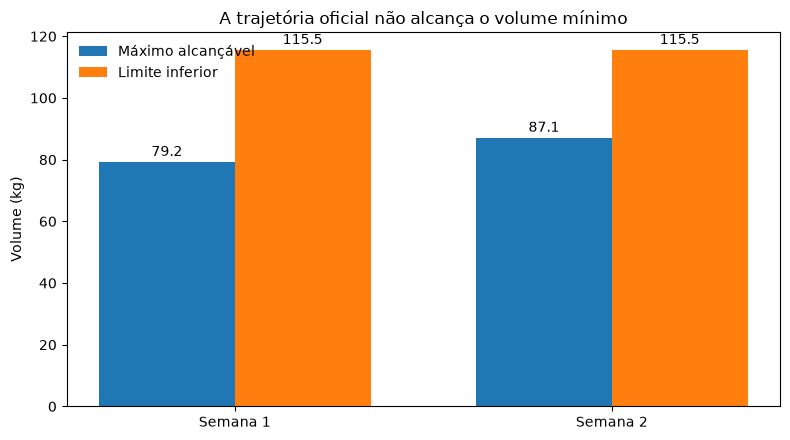

In [5]:
official_weeks = pd.DataFrame.from_dict(official['diagnostic']['weeks'], orient='index')
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(official_weeks))
ax.bar(x - 0.18, official_weeks['maximum_reachable_kg'], 0.36, label='Máximo alcançável')
ax.bar(x + 0.18, official_weeks['lower_kg'], 0.36, label='Limite inferior')
for index, row in enumerate(official_weeks.itertuples()):
    ax.text(index - 0.18, row.maximum_reachable_kg + 2, f'{row.maximum_reachable_kg:.1f}', ha='center')
    ax.text(index + 0.18, row.lower_kg + 2, f'{row.lower_kg:.1f}', ha='center')
ax.set_xticks(x, ['Semana 1', 'Semana 2'])
ax.set_ylabel('Volume (kg)')
ax.set_title('A trajetória oficial não alcança o volume mínimo')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / '03_infactibilidade_oficial.png', dpi=180, bbox_inches='tight')
plt.show()

**Interpretação.** A distância visual não é pequena nem puramente numérica: faltam 31,4% e 24,6% do próprio limite inferior nas semanas. Portanto, aumentar tolerâncias do solver não resolveria o problema operacional.

## 5. Relaxações mínimas em duas etapas

**Pergunta.** Quanto cada regra precisaria mudar, isoladamente, para recuperar viabilidade?

**Método.** Primeiro minimiza-se a alteração; depois ela é fixada e a margem é maximizada. Compara-se retirar a ligação inicial, aumentar toda variação, liberar apenas a transição inicial e reduzir a exigência de volume. O suporte nunca é relaxado.

In [6]:
without_initial = optimize_prices(problem, enforce_initial=False, seed=SEED)
minimum_daily = minimum_relaxation(
    problem, kind='daily_variation', precision=0.001
)
minimum_initial = minimum_relaxation(
    problem, kind='initial_transition', precision=0.001
)
volume_changes = volume_relaxations(problem)
relaxations = pd.DataFrame([
    {
        'alternativa': 'desconsiderar_preco_inicial',
        'alteracao': abs(without_initial['daily']['variacao_preco_rs'].iloc[0]),
        'unidade': 'R$/kg no salto observado',
        'status': without_initial['status'],
        'margem_rs': without_initial['total_margin_rs'],
    },
    {
        'alternativa': 'aumentar_variacao_todos_dias',
        'alteracao': minimum_daily['minimum'],
        'unidade': 'R$/kg por transição',
        'status': minimum_daily['status'],
        'margem_rs': minimum_daily['solution']['total_margin_rs'],
    },
    {
        'alternativa': 'liberar_apenas_transicao_inicial',
        'alteracao': minimum_initial['minimum'],
        'unidade': 'R$/kg em 31/10→03/11',
        'status': minimum_initial['status'],
        'margem_rs': minimum_initial['solution']['total_margin_rs'],
    },
    {
        'alternativa': 'reduzir_meta_nominal_comum',
        'alteracao': volume_changes['maximum_common_target_kg'],
        'unidade': 'kg de nova meta máxima',
        'status': 'viavel_no_envelope',
        'margem_rs': np.nan,
    },
    {
        'alternativa': 'aumentar_tolerancia_comum',
        'alteracao': volume_changes['minimum_common_tolerance'],
        'unidade': 'fração da meta',
        'status': 'viavel_no_envelope',
        'margem_rs': np.nan,
    },
])
relaxations.to_csv(TABLES / '03_relaxacoes_minimas.csv', index=False)
display(relaxations)

,alternativa,alteracao,unidade,status,margem_rs
0,desconsiderar_preco_inicial,107.030927,R$/kg no salto observado,optimal,59293.585523
1,aumentar_variacao_todos_dias,16.098656,R$/kg por transição,optimal,52073.475133
2,liberar_apenas_transicao_inicial,41.475609,R$/kg em 31/10→03/11,optimal,46421.152274
3,reduzir_meta_nominal_comum,113.145039,kg de nova meta máxima,viavel_no_envelope,NaN
4,aumentar_tolerancia_comum,0.519991,fração da meta,viavel_no_envelope,NaN


**Interpretação.** Manter a ligação inicial exige R$ 16,10 entre todas as decisões; preservar R$ 2,00 dentro do horizonte exige um salto inicial mínimo de aproximadamente R$ 41,48. Sem mudar preço, a meta comum teria de cair de 165 para no máximo 113,15 kg ou a tolerância subir de 30% para cerca de 52,0%. As unidades não são somadas em uma penalidade arbitrária.

## 6. Fronteira de Pareto

**Pergunta.** Quais combinações de salto inicial, variação diária e déficit não são dominadas?

**Método.** Uma grade inclui o caso oficial e vizinhanças das relaxações mínimas. Um ponto é removido se outro não piora nenhuma das três dimensões e melhora ao menos uma. A grade aproxima a fronteira; decisões comerciais entre unidades distintas continuam necessárias.

,salto_inicial_max_rs,variacao_diaria_max_rs,deficit_total_kg
0,10.000000,20.000000,0.000000
1,20.000000,16.098656,0.000000
2,30.000000,10.000000,0.000000
3,41.475609,2.000000,0.000000
4,10.000000,16.098656,6.628729
5,30.000000,5.000000,6.880453
6,2.000000,20.000000,7.064164
7,20.000000,10.000000,8.057605
8,30.000000,2.000000,13.759256
9,2.000000,16.098656,14.712414


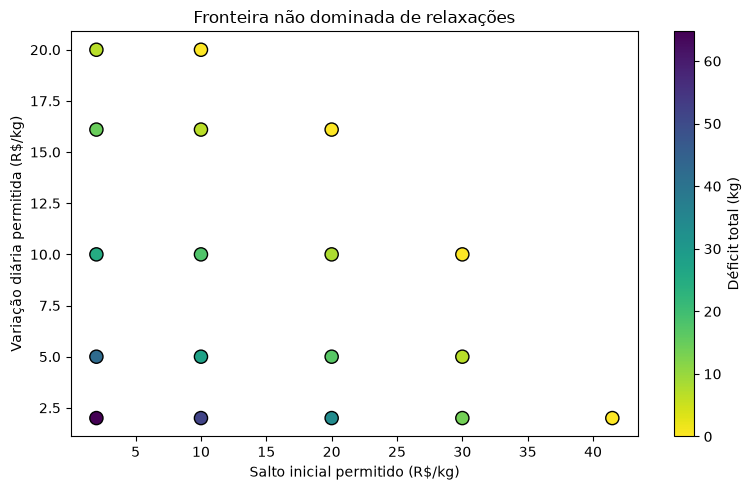

In [7]:
initial_grid = [2, 10, 20, 30, float(minimum_initial['minimum']), 50, 75, 110]
daily_grid = [2, 5, 10, float(minimum_daily['minimum']), 20]
pareto = pareto_relaxations(
    problem, initial_grid=initial_grid, daily_grid=daily_grid
)
pareto.to_csv(TABLES / '03_pareto_relaxacoes.csv', index=False)
display(pareto)

fig, ax = plt.subplots(figsize=(8, 5))
points = ax.scatter(
    pareto['salto_inicial_max_rs'], pareto['variacao_diaria_max_rs'],
    c=pareto['deficit_total_kg'], s=90, cmap='viridis_r', edgecolor='black',
)
ax.set_xlabel('Salto inicial permitido (R$/kg)')
ax.set_ylabel('Variação diária permitida (R$/kg)')
ax.set_title('Fronteira não dominada de relaxações')
fig.colorbar(points, ax=ax, label='Déficit total (kg)')
fig.tight_layout()
fig.savefig(FIGURES / '03_fronteira_pareto.png', dpi=180, bbox_inches='tight')
plt.show()

**Interpretação.** A fronteira torna o compromisso explícito: conservar a estabilidade de R$ 2,00 transfere a alteração para a entrada no horizonte; limitar o salto inicial requer quedas maiores ao longo dos dias; manter ambos produz déficit. Não existe uma única escolha matemática sem preferência operacional.

## 7. Planos factíveis e baselines

**Pergunta.** Como ficam preço, volume e margem após cada recuperação explícita?

**Método.** Somente resultados validados recebem plano diário. O caso oficial, manter o preço e o ótimo sem meta permanecem como baselines diagnósticos. A alternativa destacada preserva R$ 2,00 dentro das duas semanas e altera apenas a transição inicial.

,semana,volume_previsto_kg,margem_prevista_rs,preco_medio_kg,meta_kg,limite_inferior_kg,limite_superior_kg,alternativa
0,semana_1,214.500000,29646.792761,1211.887974,165.0,115.5,214.5,sem_ligacao_inicial
1,semana_2,214.500000,29646.792761,1211.888208,165.0,115.5,214.5,sem_ligacao_inicial
2,semana_1,115.504213,22455.319066,1270.623626,165.0,115.5,214.5,variacao_diaria_minima
3,semana_2,214.500000,29618.156066,1211.596867,165.0,115.5,214.5,variacao_diaria_minima
4,semana_1,115.501724,22644.002371,1273.443985,165.0,115.5,214.5,transicao_inicial_minima
5,semana_2,127.321701,23777.149904,1263.443985,165.0,115.5,214.5,transicao_inicial_minima


,baseline,status,margem_rs
0,oficial,infeasible,NaN
1,manter_preco_inicial,factível sem meta,35818.629057
2,preco_constante_para_meta,optimal,59293.585523
3,otimo_sem_meta,optimal,37887.705280
4,otimo_sem_variacao,optimal,57320.357301


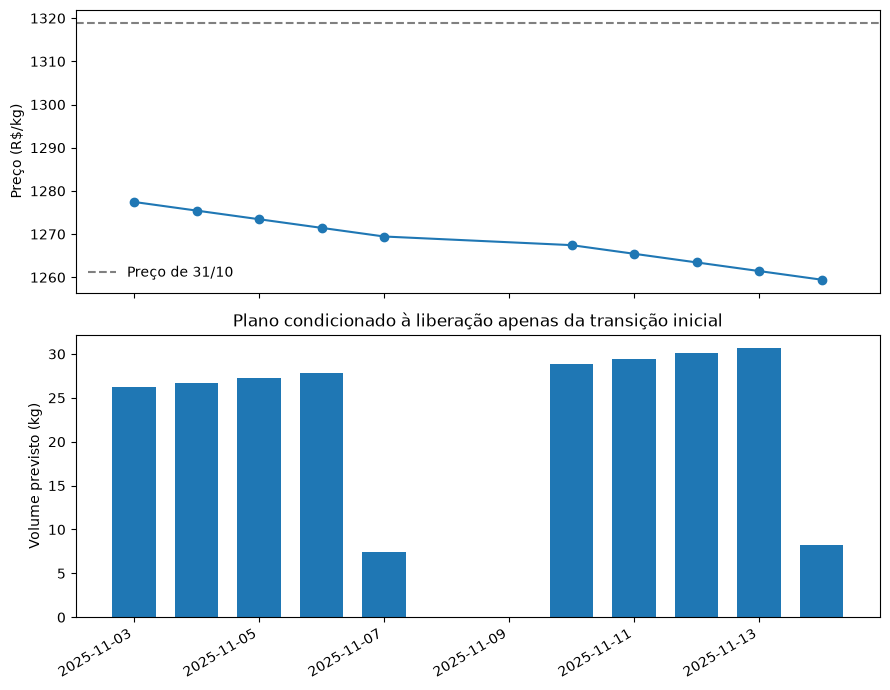

In [8]:
solutions = {
    'sem_ligacao_inicial': without_initial,
    'variacao_diaria_minima': minimum_daily['solution'],
    'transicao_inicial_minima': minimum_initial['solution'],
}
daily_plans = pd.concat(
    [result['daily'].assign(alternativa=name) for name, result in solutions.items()],
    ignore_index=True,
)
weekly_plans = pd.concat(
    [result['weekly'].assign(alternativa=name) for name, result in solutions.items()],
    ignore_index=True,
)
daily_plans.to_csv(DATA / 'processed' / 'minerva_plano_precos.csv', index=False)
weekly_plans.to_csv(TABLES / '03_planos_resumo_semanal.csv', index=False)
display(weekly_plans)

no_target = optimize_prices(problem, enforce_targets=False, seed=SEED)
no_variation = optimize_prices(problem, enforce_variation=False, seed=SEED)
constant_target = optimize_prices(
    problem, enforce_initial=False, daily_delta=0.0, seed=SEED
)
constant_prices = np.repeat(problem.initial_price, problem.n_days)
constant_check = validate_prices(
    problem, constant_prices, initial_delta=2, daily_delta=2
)
baseline_rows = [
    {'baseline': 'oficial', 'status': official['status'], 'margem_rs': np.nan},
    {'baseline': 'manter_preco_inicial', 'status': 'factível sem meta' if not constant_check['targets_ok'] else 'factível', 'margem_rs': margin_vector(problem, constant_prices).sum()},
    {'baseline': 'preco_constante_para_meta', 'status': constant_target['status'], 'margem_rs': constant_target['total_margin_rs']},
    {'baseline': 'otimo_sem_meta', 'status': no_target['status'], 'margem_rs': no_target['total_margin_rs']},
    {'baseline': 'otimo_sem_variacao', 'status': no_variation['status'], 'margem_rs': no_variation['total_margin_rs']},
]
baselines = pd.DataFrame(baseline_rows)
baselines.to_csv(TABLES / '03_baselines.csv', index=False)
display(baselines)

recommended = minimum_initial['solution']
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
rec_daily = recommended['daily']
axes[0].plot(rec_daily['data'], rec_daily['preco_kg'], marker='o')
axes[0].axhline(problem.initial_price, color='gray', linestyle='--', label='Preço de 31/10')
axes[0].set_ylabel('Preço (R$/kg)')
axes[0].legend(frameon=False)
axes[1].bar(rec_daily['data'], rec_daily['volume_previsto_kg'], width=0.7)
axes[1].set_ylabel('Volume previsto (kg)')
axes[1].set_title('Plano condicionado à liberação apenas da transição inicial')
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / '03_trajetoria_recomendacao.png', dpi=180, bbox_inches='tight')
plt.show()

**Interpretação.** A alternativa condicionada a um salto inicial de cerca de R$ 41,48 cumpre ambas as semanas e preserva mudanças de R$ 2,00 depois de 03/11. Ela não é uma recomendação incondicional: depende de a operação aceitar a exceção na fronteira. O ótimo sem meta confirma que a margem prevista favorece reduções de preço, mas ainda não consegue cumprir a meta sob as regras oficiais.

## 8. Sensibilidades de demanda, custo, imposto, meta e variação

**Pergunta.** Os planos continuam factíveis e financeiramente atrativos quando premissas plausíveis mudam?

**Método.** Cada política central é reaplicada, sem reotimização oportunista, aos três multiplicadores de demanda, três custos e quatro alíquotas. Separadamente, metas de 80% a 120% e limites de R$ 0, 1, 2, 5, 10 e ilimitado são diagnosticados. Multiplicadores alteram nível, não elasticidade; essa é uma limitação importante.

,politica,cenario_demanda,margem_minima_rs,margem_maxima_rs,frequencia_meta
0,sem_ligacao_inicial,central,34885.349693,95754.866349,0.0
1,sem_ligacao_inicial,conservador,18095.425711,49669.132910,0.0
2,sem_ligacao_inicial,otimista,61114.156975,167748.868355,0.0
3,transicao_inicial_minima,central,32190.726175,68026.971162,1.0
4,transicao_inicial_minima,conservador,16697.693995,35286.359858,0.0
5,transicao_inicial_minima,otimista,56393.560905,119173.550809,0.0
6,variacao_diaria_minima,central,33089.203535,80607.392680,0.0
7,variacao_diaria_minima,conservador,17163.744371,41811.966881,0.0
8,variacao_diaria_minima,otimista,57967.565091,141212.654966,0.0


,fator_meta,variacao_rs,viavel,deficit_total_kg
0,0.8,0.0,False,34.144993
1,0.8,1.0,False,26.613479
2,0.8,2.0,False,18.548038
3,0.8,5.0,False,6.881869
4,0.8,10.0,True,0.000000
5,0.8,inf,True,0.000000
6,0.9,0.0,False,57.244993
7,0.9,1.0,False,49.713479
8,0.9,2.0,False,41.648038
9,0.9,5.0,False,18.431869


,tolerancia,limite_inferior_kg,viavel,deficit_total_kg
0,0.050000,156.750000,False,147.248038
1,0.300000,115.500000,False,64.748038
2,0.519991,79.201528,True,0.000000


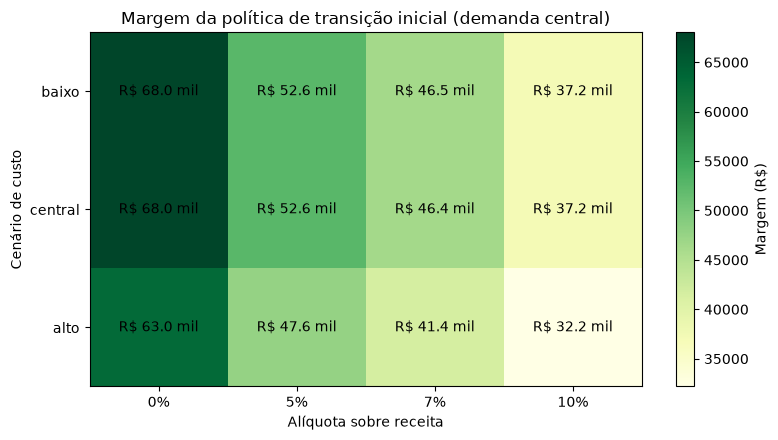

In [9]:
scenario_rows = []
cost_scenarios = {
    'baixo': cost_selection['low_cost_kg'],
    'central': cost_selection['forecast_cost_kg'],
    'alto': cost_selection['high_cost_kg'],
}
for policy_name, result in solutions.items():
    prices = result['daily']['preco_kg'].to_numpy()
    for demand_scenario in ['conservador', 'central', 'otimista']:
        for cost_name, cost_value in cost_scenarios.items():
            for tax_rate in [0.00, 0.05, 0.07, 0.10]:
                scenario_problem = replace(
                    problem, scenario=demand_scenario, unit_cost=cost_value, tax_rate=tax_rate
                )
                volumes = demand_vector(scenario_problem, prices)
                weekly_volumes = {
                    week: volumes[np.array(problem.weeks) == week].sum()
                    for week in problem.targets
                }
                scenario_rows.append({
                    'politica': policy_name, 'cenario_demanda': demand_scenario,
                    'cenario_custo': cost_name, 'imposto': tax_rate,
                    'margem_total_rs': margin_vector(scenario_problem, prices).sum(),
                    'volume_minimo_semanal_kg': min(weekly_volumes.values()),
                    'meta_atendida': all(
                        problem.targets[w] * (1 - problem.tolerance) <= value
                        <= problem.targets[w] * (1 + problem.tolerance)
                        for w, value in weekly_volumes.items()
                    ),
                })
scenario_matrix = pd.DataFrame(scenario_rows)
scenario_matrix.to_csv(TABLES / '03_sensibilidade_cenarios.csv', index=False)
display(
    scenario_matrix.groupby(['politica', 'cenario_demanda'])
    .agg(margem_minima_rs=('margem_total_rs', 'min'), margem_maxima_rs=('margem_total_rs', 'max'),
         frequencia_meta=('meta_atendida', 'mean'))
    .reset_index()
)

grid_rows = []
for factor in [0.8, 0.9, 1.0, 1.1, 1.2]:
    grid_problem = replace(
        problem, targets={week: target * factor for week, target in problem.targets.items()}
    )
    for variation in [0.0, 1.0, 2.0, 5.0, 10.0, None]:
        diagnostic = diagnose_feasibility(
            grid_problem, initial_delta=variation, daily_delta=variation
        )
        grid_rows.append({
            'fator_meta': factor, 'variacao_rs': np.inf if variation is None else variation,
            'viavel': diagnostic['potentially_feasible'],
            'deficit_total_kg': sum(v['shortage_kg'] for v in diagnostic['weeks'].values()),
        })
meta_variation = pd.DataFrame(grid_rows)
meta_variation.to_csv(TABLES / '03_sensibilidade_meta_variacao.csv', index=False)
display(meta_variation)

tolerance_rows = []
for tolerance in [0.05, 0.30, volume_changes['minimum_common_tolerance']]:
    tolerance_problem = replace(problem, tolerance=float(tolerance))
    diagnostic = diagnose_feasibility(tolerance_problem)
    tolerance_rows.append({
        'tolerancia': tolerance,
        'limite_inferior_kg': 165 * (1 - tolerance),
        'viavel': diagnostic['potentially_feasible'],
        'deficit_total_kg': sum(v['shortage_kg'] for v in diagnostic['weeks'].values()),
    })
tolerance_sensitivity = pd.DataFrame(tolerance_rows)
tolerance_sensitivity.to_csv(
    TABLES / '03_sensibilidade_tolerancia.csv', index=False
)
display(tolerance_sensitivity)

central_rec = scenario_matrix.query(
    "politica == 'transicao_inicial_minima' and cenario_demanda == 'central'"
).pivot(index='cenario_custo', columns='imposto', values='margem_total_rs')
central_rec = central_rec.reindex(['baixo', 'central', 'alto'])
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(central_rec, aspect='auto', cmap='YlGn')
ax.set_xticks(range(len(central_rec.columns)), [f'{x:.0%}' for x in central_rec.columns])
ax.set_yticks(range(len(central_rec.index)), central_rec.index)
ax.set_xlabel('Alíquota sobre receita')
ax.set_ylabel('Cenário de custo')
ax.set_title('Margem da política de transição inicial (demanda central)')
for i in range(len(central_rec.index)):
    for j in range(len(central_rec.columns)):
        ax.text(j, i, f'R$ {central_rec.iloc[i, j]/1000:.1f} mil', ha='center', va='center')
fig.colorbar(image, ax=ax, label='Margem (R$)')
fig.tight_layout()
fig.savefig(FIGURES / '03_sensibilidade_custo_imposto.png', dpi=180, bbox_inches='tight')
plt.show()

**Interpretação.** Custo e imposto alteram margem, mas não a viabilidade de volume de uma política fixa. Já o cenário conservador de demanda pode tornar planos centrais infactíveis, evidenciando que cumprir a meta na curva central não é proteção robusta. A grade confirma que pequenos aumentos de R$ 2 para R$ 5 ou R$ 10 ainda não bastam na formulação que liga todos os movimentos ao preço inicial. A tolerância textual de 5% também é infactível e mais restritiva que os 30% da instância. O caso de imposto zero é margem antes de impostos, não margem líquida.

## 9. Avaliação ex post e persistência

**Pergunta.** Os resultados podem ser reproduzidos sem estado oculto e comparados, depois da decisão, ao período observado?

**Método.** Só agora o holdout é lido para um baseline histórico ex post. JSONs guardam entradas, hash, diagnóstico e relaxações; CSVs guardam planos e sensibilidades. O histórico não redefine custo, curva ou política.

In [10]:
holdout = pd.read_csv(DATA / 'interim' / 'minerva_holdout.csv', parse_dates=['Data'])
holdout_ex_post_margin = float(
    ((1 - problem.tax_rate) * holdout['Receita Realizada (R$)']
     - holdout['Custo Realizado (R$)']).sum()
)
baselines = pd.concat([
    baselines,
    pd.DataFrame([{'baseline': 'precos_historicos_holdout_ex_post', 'status': 'observado depois da decisão', 'margem_rs': holdout_ex_post_margin}]),
], ignore_index=True)
baselines.to_csv(TABLES / '03_baselines.csv', index=False)
display(baselines)

def json_ready(value):
    if isinstance(value, (np.floating, np.integer, np.bool_)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (pd.Timestamp, np.datetime64)):
        return pd.Timestamp(value).isoformat()
    raise TypeError(f'Tipo não serializável: {type(value)!r}')

diagnostic_payload = {
    'model_core_sha256': artifact['model_core_sha256'],
    'status': official['status'],
    'official': official['diagnostic'],
    'nested': nested_diagnostics,
    'volume_relaxations': volume_changes,
}
with (DATA / 'processed' / 'minerva_diagnostico_infactividade.json').open('w', encoding='utf-8') as file:
    json.dump(diagnostic_payload, file, ensure_ascii=False, indent=2, default=json_ready)

result_payload = {
    'artifact_version': artifact['artifact_version'],
    'model_core_sha256': artifact['model_core_sha256'],
    'cost_selection': {key: value for key, value in cost_selection.items() if key not in {'details', 'summary'}},
    'tax_rate': problem.tax_rate,
    'initial_price': problem.initial_price,
    'official_status': official['status'],
    'official_validation': None,
    'restrictions': {
        'targets_kg': dict(problem.targets),
        'tolerance': problem.tolerance,
        'daily_variation': problem.daily_variation,
    },
    'minimum_daily_variation': minimum_daily['minimum'],
    'minimum_initial_transition': minimum_initial['minimum'],
    'recommended_policy': 'transicao_inicial_minima',
    'recommendation_condition': 'aceitar exceção apenas entre 31/10 e 03/11',
    'recommended_daily': recommended['daily'].to_dict(orient='records'),
    'recommended_weekly': recommended['weekly'].to_dict(orient='records'),
    'recommended_validation': recommended['validation'],
    'alternatives': {
        name: {
            'status': result['status'],
            'total_margin_rs': result['total_margin_rs'],
            'validation': result['validation'],
        }
        for name, result in solutions.items()
    },
    'tables': {
        'cost_validation': 'reports/tables/03_custo_validacao_resumo.csv',
        'relaxations': 'reports/tables/03_relaxacoes_minimas.csv',
        'pareto': 'reports/tables/03_pareto_relaxacoes.csv',
        'scenario_sensitivity': 'reports/tables/03_sensibilidade_cenarios.csv',
        'target_variation_sensitivity': 'reports/tables/03_sensibilidade_meta_variacao.csv',
        'tolerance_sensitivity': 'reports/tables/03_sensibilidade_tolerancia.csv',
    },
}
with (DATA / 'processed' / 'minerva_otimizacao_resultado.json').open('w', encoding='utf-8') as file:
    json.dump(result_payload, file, ensure_ascii=False, indent=2, default=json_ready)

required_outputs = [
    DATA / 'processed' / 'minerva_diagnostico_infactividade.json',
    DATA / 'processed' / 'minerva_plano_precos.csv',
    DATA / 'processed' / 'minerva_otimizacao_resultado.json',
    FIGURES / '03_infactibilidade_oficial.png',
    FIGURES / '03_fronteira_pareto.png',
    FIGURES / '03_trajetoria_recomendacao.png',
    FIGURES / '03_sensibilidade_custo_imposto.png',
]
missing = [str(path) for path in required_outputs if not path.exists()]
if missing:
    raise FileNotFoundError(missing)
print('Entregáveis validados:', len(required_outputs))

,baseline,status,margem_rs
0,oficial,infeasible,NaN
1,manter_preco_inicial,factível sem meta,35818.629057
2,preco_constante_para_meta,optimal,59293.585523
3,otimo_sem_meta,optimal,37887.705280
4,otimo_sem_variacao,optimal,57320.357301
5,precos_historicos_holdout_ex_post,observado depois da decisão,39107.830245


Entregáveis validados: 7


**Interpretação.** A comparação histórica é estritamente ex post e não muda a recomendação. Todos os resultados centrais carregam o hash da curva, a regra de custo e a alteração operacional correspondente, permitindo auditoria sem copiar coeficientes para o otimizador.

## 10. Conclusão condicionada

- **Evidência histórica:** a curva observacional prevê forte queda de volume na faixa de preços alcançável a partir de 31/10; estoque, concorrência e causalidade de preço permanecem não observados.
- **Premissas:** custo de R$ 988,84/kg foi escolhido no desenvolvimento; imposto central é 7%; preços são contínuos.
- **Resultado matemático:** o caso oficial é infactível, com máximos de 79,20 kg e 87,05 kg. A menor exceção restrita à entrada é um salto de aproximadamente R$ 41,48, mantendo R$ 2,00 depois disso.
- **Recomendação condicionada:** adotar o plano `transicao_inicial_minima` somente se a operação aceitar formalmente essa exceção e sua exposição ao cenário conservador. Caso contrário, não existe plano diário válido sob as regras atuais.
- **Validação futura:** confirmar incrementos comerciais de preço, proteção desejada contra demanda conservadora e obter dados de estoque, promoções, concorrentes e preço de lista.